# 3. Default Prediction: Logistic Regression with Feature Selection 

#### Outline of this notebook:  
* **Section 1:** Objective
* **Section 2:** Load Cleaned Dataset
* **Section 3:** Feature Preprocessing
  * 3.1: Define feature types
  * 3.2: Train-test split (time-based)
  * 3.3: Build Preprocessing Pipeline
* **Section 4:** Logistic Regression – Feature Set Comparison  
  * 4.1: Full Feature Set  
  * 4.2: Intuition-Based Feature Set  
  * 4.3: Filter-Based Feature Selection  
  * 4.4: LASSO-Based Feature Selection  
  * 4.5: Permutation-Based Feature Selection
* **Section 5:** Model Comparisons
  * 5.1: Threshold Selection Using Precision–Recall Trade-off
  * 5.2: Discriminatory Power (AUC / Gini)
  * 5.3: Calibration + Classification Metrics
  * 5.4: Interpretation
* **Section 6:** Feature Importance
  * 6.1: Coefficient-based feature importance (Full vs Permutation models)
  * 6.2: Permutation importance on test set
* **Section 7:** Discussions

---
## Section 1: Objective

The goal of this notebook is to build a **logistic regression model to predict loan default** and evaluate how different **feature selection strategies** affect model performance.

Logistic regression is one of the **most widely used** methods for credit risk modeling, especially for predicting loan default, because it provides probabilistic outputs and is easy to interpret. In practice, it remains a standard approach in banks and financial institutions, particularly for regulatory and production models such as credit scoring. Its transparency, stability, and ease of validation make it well-suited for meeting regulatory requirements.

We compare multiple approaches—from using all features to more targeted selections based on intuition and data-driven methods (e.g., LASSO, permutation importance)—to understand:

- Which features are most useful for predicting default  
- How model performance changes with different feature sets  
- Whether simpler, well-chosen features can perform as well as or better than the full set  

This helps identify a robust, interpretable, and practically useful model for credit risk prediction.

---
## Section 2: Load Cleaned Dataset 

In [4]:
import pandas as pd 
import sys
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, log_loss,
    brier_score_loss, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_selection import SelectKBest, f_classif

In [5]:
df_cleaned = pd.read_parquet("../data/processed/LendingClub_features.parquet")

In [6]:
df_cleaned.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,payment_to_income,fico_util_interaction,inq_per_credit_year,dti_x_int_rate,loan_to_installment,delinq_rate,fico_band,dti_band,unemployment_rate,fed_funds_rate
0,5000.0,36.0,0.1065,162.87,B,B2,10.0,RENT,24000.0,Verified,...,0.069444,615.195,0.024183,2.944725,30.699331,0.0,good,medium,8.5,0.07
1,2500.0,60.0,0.1527,59.83,C,C4,0.5,RENT,30000.0,Source Verified,...,0.016667,69.560,0.184530,0.152700,41.785057,0.0,good,very_low,8.5,0.07
2,2400.0,36.0,0.1596,84.33,C,C5,10.0,RENT,12252.0,Not Verified,...,0.065295,723.975,0.081610,1.391712,28.459623,0.0,good,very_low,8.5,0.07
3,10000.0,36.0,0.1349,339.31,C,C1,10.0,RENT,49200.0,Source Verified,...,0.067751,144.900,0.033047,2.698000,29.471575,0.0,good,low,8.5,0.07
4,3000.0,60.0,0.1269,67.79,B,B5,1.0,RENT,80000.0,Source Verified,...,0.007500,374.605,0.000000,2.276586,44.254314,0.0,good,low,8.5,0.07


#### Limit to pre-COVID loans

To ensure a stable and consistent economic environment, I exclude observations from the COVID-19 period and restrict the analysis to loans issued up to 2019. This avoids potential distortions driven by the unprecedented shocks during the pandemic.

In [8]:
df_cleaned['issue_d'].agg(['min', 'max'])

min   2007-06-01
max   2020-09-01
Name: issue_d, dtype: datetime64[ns]

In [9]:
print(f"Number of observations before restricting to 2019-12-01: {df_cleaned.shape[0]:,}")

Number of observations before restricting to 2019-12-01: 1,860,765


In [10]:
df_cleaned = df_cleaned[df_cleaned['issue_d'] <= '2019-12-01']

In [11]:
print(f"Number of observations after restricting to 2019-12-01: {df_cleaned.shape[0]:,}")

Number of observations after restricting to 2019-12-01: 1,856,478


---
## Section 3: Feature Preprocessing

In this section, I prepare the features for modeling by combining direct data cleaning with a reusable preprocessing pipeline.

The main steps are as follows:

- **3.1: Define feature types**: Separate variables into numerical and categorical features.

- **3.2: Train-test split**

- **3.3: Build preprocessing pipeline**:
  - **Categorical variables**: Impute missing values using the most frequent value and apply one-hot encoding, converting each category into binary (0/1) indicator variables.
  - **Numerical variables**: Impute missing values using the median and apply feature scaling (standardization) for linear models (e.g. logistic regression, LASSO) that are sensitive to scale. 
  - These steps are implemented using `ColumnTransformer` and `Pipeline` from `sklearn`, and are applied during model training rather than directly modifying `df_cleaned`. This ensures consistency, reproducibility, and prevents data leakage.

### 🔷 3.1: Define feature types

In [14]:
# 1. Target variable
target = 'default'

# 2. Variables to drop (before modeling)
drop_cols = ['zip_code', 'grade', 'addr_state']  
    # grade: 
    #  - redundant to 'sub_grade' (see 2_exploratory_data_analysis)
    # addr_state, zip_code:
    #  - will drop geographic variables 
    #    to avoid potential proxy effects for protected characteristics
    #    and mitigate fairness / regulatory concerns in credit risk modeling.

# 3. Time-related (handle separately)
date_cols = ['issue_d']

# 4. Categorical features
categorical_cols = [
    'sub_grade', 
    'home_ownership', 'verification_status',
    'purpose',
    'initial_list_status', 'application_type',
    'fico_band', 'dti_band'
]

# 5. Numeric features (all the others)
numeric_cols = [
    col for col in df_cleaned.columns
    if col not in categorical_cols + date_cols + drop_cols + [target]
]

# 6. Final check
print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))
print("Date:", date_cols)

Numeric: 62
Categorical: 8
Date: ['issue_d']


In [15]:
# print(numeric_cols) ## Checking numeric features 

### 🔷 3.2: Train-validation-test split (time-based)

We use a **time-based** train–validation–test split to mimic the real-world setting where the model is trained on past loans, tuned on a more recent validation period, and evaluated on future loans. 

This ensures the model only uses past data to predict future outcomes, just like in real-world lending. It also gives a more reliable evaluation of both model tuning and how the model will perform on truly new loans.

In [17]:
# Start from original data
X = df_cleaned.copy()

# Drop unnecessary columns
X = X.drop(columns=[col for col in drop_cols if col in X.columns])

# Target
y = df_cleaned[target]

# Combine
df_model = X.copy()
df_model[target] = y

# Sort by issue date
df_model = df_model.sort_values("issue_d")

# Split indices
n = len(df_model)
train_end = int(n * 0.6)
val_end   = int(n * 0.8)

# Split data (time-based)
X_train = df_model.iloc[:train_end].drop(columns=[target])
y_train = df_model.iloc[:train_end][target]

X_val = df_model.iloc[train_end:val_end].drop(columns=[target])
y_val = df_model.iloc[train_end:val_end][target]

X_test = df_model.iloc[val_end:].drop(columns=[target])
y_test = df_model.iloc[val_end:][target]

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (1113886, 71)
Validation size: (371296, 71)
Test size: (371296, 71)


In [18]:
# Check date ranges
print(f"Train date range: {X_train['issue_d'].min().date()} → {X_train['issue_d'].max().date()}")
print(f"Validation date range: {X_val['issue_d'].min().date()} → {X_val['issue_d'].max().date()}")
print(f"Test date range: {X_test['issue_d'].min().date()} → {X_test['issue_d'].max().date()}")

Train date range: 2007-06-01 → 2016-07-01
Validation date range: 2016-07-01 → 2017-08-01
Test date range: 2017-08-01 → 2019-12-01


In [19]:
# [Important] Drop time variable (not used for prediction)
X_train = X_train.drop(columns=["issue_d"])
X_val = X_val.drop(columns=["issue_d"])
X_test  = X_test.drop(columns=["issue_d"])

### 🔷 3.3: Build Preprocessing Pipeline

To ensure consistent and reproducible feature transformations, I construct a preprocessing pipeline using `ColumnTransformer` and `Pipeline` from `sklearn`.

- **Categorical variables**:
  - Missing values are imputed using the most frequent value.
  - Variables are then one-hot encoded, where each category is converted into a binary (0/1) indicator variable.

- **Numerical variables**:
  - Missing values are imputed using the median.
  - Features are standardized (mean 0, unit variance) for models that are sensitive to scale, such as Logistic Regression and LASSO.

These transformations are applied within the modeling pipeline during training, rather than directly modifying the dataset. This approach ensures that the same preprocessing steps are consistently applied to both training and test data, and helps prevent data leakage.

In [21]:
# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Numerical pipeline (with scaling for logit/LASSO)
num_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Combined preprocessor
preprocessor_scaled = ColumnTransformer([
    ("num", num_pipeline_scaled, numeric_cols),
    ("cat", cat_pipeline, categorical_cols)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


---
## Section 4:  Logistic Regression – Feature Set Comparison  

In this section, we estimate logistic regression models using different feature sets to examine how feature selection affects predictive performance.

We begin with a **full set** of available features as a benchmark. 
We then compare this to several alternative approaches: 
* an **intuition-based** subset guided by domain knowledge
* a **filter-based** method using univariate statistical tests
* a **LASSO-based** approach that performs embedded feature selection through regularization
* a **permutation-based** method that selects features based on their impact on model performance

This setup allows us to study the trade-offs between model simplicity, interpretability, and predictive power. Model performance across these specifications is evaluated and compared in Section 5.

### 🔷 4.0: Helper functions

In [24]:
## Helper: build preprocessor for a given feature set

def build_preprocessor(feature_set):
    num_cols = [col for col in numeric_cols if col in feature_set]
    cat_cols = [col for col in categorical_cols if col in feature_set]
    
    return ColumnTransformer([
        ("num", num_pipeline_scaled, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ])

In [25]:
def tune_logit_model(feature_set, X_train, y_train, X_val, y_val):
    """
    Step 1: Find best hyperparameters using validation AUC.
    Step 2: Refit final model on train + val combined with best params.
    Returns the refitted model, best params, and best validation AUC.
    """
    C_grid = [0.01, 0.1, 1, 10]
    penalty_grid = ["l2"]

    best_auc = -1
    best_params = None

    X_train_sub = X_train[feature_set]
    X_val_sub   = X_val[feature_set]

    # --- Step 1: tune on train/val ---
    for C in C_grid:
        for penalty in penalty_grid:
            try:
                preprocessor = build_preprocessor(feature_set)
                pipeline = Pipeline([
                    ("preprocess", preprocessor),
                    ("model", LogisticRegression(
                        C=C,
                        penalty=penalty,
                        solver="lbfgs",
                        max_iter=1000,
                        random_state=42
                    ))
                ])
                pipeline.fit(X_train_sub, y_train)
                y_val_pred = pipeline.predict_proba(X_val_sub)[:, 1]
                auc = roc_auc_score(y_val, y_val_pred)

                if auc > best_auc:
                    best_auc = auc
                    best_params = {"C": C, "penalty": penalty}

            except:
                continue

    # --- Step 2: refit on train + val with best params ---
    X_trainval = pd.concat([X_train_sub, X_val_sub])
    y_trainval = pd.concat([y_train, y_val])

    final_preprocessor = build_preprocessor(feature_set)
    best_model = Pipeline([
        ("preprocess", final_preprocessor),
        ("model", LogisticRegression(
            C=best_params["C"],
            penalty=best_params["penalty"],
            solver="lbfgs",
            max_iter=1000,
            random_state=42
        ))
    ])
    best_model.fit(X_trainval, y_trainval)

    return best_model, best_params, best_auc

### 🔷 4.1: Full feature set

In [27]:
features_full = X_train.columns.tolist()

start = time.time()
## Train model with hyperparameter tuning
logit_full, params_full, val_auc_full = tune_logit_model(
    features_full,
    X_train, y_train,
    X_val, y_val
)

print("Run time:", time.strftime("%H:%M:%S", time.gmtime(time.time() - start)))
print("Best params:", params_full)
print("Validation AUC:", val_auc_full)

Run time: 00:02:50
Best params: {'C': 10, 'penalty': 'l2'}
Validation AUC: 0.7146834625049039


### 🔷 4.2: Intuition-based feature set

In this specification, we construct a feature set based on economic intuition and domain knowledge of credit risk. The selected variables capture key dimensions associated with a borrower's likelihood of default:

- **Loan characteristics:**  
  `loan_amnt`, `term`, `int_rate`, and `sub_grade` reflect loan terms and pricing.

- **Borrower capacity (ability to pay):**  
  `annual_inc`, `emp_length`, and `dti` capture income and repayment burden.

- **Credit history and behavior:**  
  `fico_range_low`, `inq_last_6mths`, `open_acc`, `pub_rec`, `total_acc`, and `credit_age` summarize creditworthiness, past usage, and length of credit history.

- **Credit utilization:**  
  `revol_bal` and `revol_util` measure current credit usage.

- **Borrower characteristics:**  
  `home_ownership`, `verification_status`, and `purpose` capture additional heterogeneity.

- **Engineered features (economically motivated):**  
  `fico_util_interaction` (FICO × revolving utilization), `dti_x_int_rate` (repayment pressure × borrowing cost), `payment_to_income` (monthly burden relative to income), `inq_per_credit_year` (inquiry intensity), and `delinq_rate` (delinquency frequency normalized by credit history length).

- **Macroeconomic conditions at origination:**  
  `unemployment_rate` and `fed_funds_rate` capture the broader economic environment at loan origination.

This parsimonious and interpretable feature set serves as a benchmark against more data-driven approaches.

In [29]:
features_intuition = [
    # Loan characteristics
    "loan_amnt", "term", "int_rate", "sub_grade",
    # Borrower capacity
    "annual_inc", "emp_length", "dti",
    # Credit history
    "fico_range_low", "inq_last_6mths", "open_acc", "pub_rec", "total_acc", "credit_age",
    # Credit utilization
    "revol_bal", "revol_util",
    # Borrower characteristics
    "home_ownership", "verification_status", "purpose",
    # Engineered features (economically motivated)
    "dti_x_int_rate",          # DTI × interest rate: compounded repayment pressure
    "payment_to_income",       # monthly payment burden relative to income
    "inq_per_credit_year",     # inquiry intensity normalized by credit history
    "delinq_rate",             # delinquency frequency normalized by credit history
    "fico_util_interaction",   # FICO × revolving utilization
    # Macroeconomic conditions at origination
    "unemployment_rate", "fed_funds_rate"
]

features_intuition = [col for col in features_intuition if col in X_train.columns]

start = time.time()
# Train model with hyperparameter tuning
logit_intuition, params_intuition, val_auc_intuition = tune_logit_model(
    features_intuition,
    X_train, y_train,
    X_val, y_val
)

print("Run time:", time.strftime("%H:%M:%S", time.gmtime(time.time() - start)))
print("Best params:", params_intuition)
print("Validation AUC:", val_auc_intuition)

Run time: 00:01:04
Best params: {'C': 10, 'penalty': 'l2'}
Validation AUC: 0.7072905479524753


### 🔷 4.3: Filter-based feature selection

In this approach, we select features based on how strongly each variable is related to the target. Specifically, we use statistical tests (ANOVA F-tests) to identify variables that are **most predictive of default.**

We apply separate procedures for numeric and categorical features.
* For **numeric features**, we first impute missing values using the median, then select the top 20 features with the highest F-statistics.
* For **categorical features**, we first impute missing values using the most frequent category, then apply one-hot encoding to convert each variable into multiple dummy variables. Feature selection is performed on these encoded features. Since selection occurs at the dummy level, we map the selected dummies back to their original variables and retain the entire categorical variable if any of its categories are selected.

The final feature set combines the top numeric and categorical variables. This method provides a simple and computationally efficient way to reduce dimensionality. 

However, a caveat of this method is that it evaluates each feature independently and does not account for interactions between variables.

In [31]:
## --- (A) For numeric features 
numeric_available = [col for col in numeric_cols if col in X_train.columns]

# 1. Impute first (otherwise, SelectKBest wouldn't work)
imputer = SimpleImputer(strategy="median")
X_num_imputed = imputer.fit_transform(X_train[numeric_available])

# 2. Then select features
selector = SelectKBest(score_func=f_classif, k=20)
selector.fit(X_num_imputed, y_train)

top_numeric_filter = np.array(numeric_available)[selector.get_support()].tolist()

In [32]:
## --- (B) For categorical features 
categorical_available = [col for col in categorical_cols if col in X_train.columns]

# 1. Impute missing values 
imputer_cat = SimpleImputer(strategy="most_frequent")
X_cat_imputed = imputer_cat.fit_transform(X_train[categorical_available])

# 2. Encode (converts each categorical variable into mutiple dummy variables) 
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat_encoded = encoder.fit_transform(X_cat_imputed)

# 3. Select top categorical features 
selector_cat = SelectKBest(score_func=f_classif, k=25)
selector_cat.fit(X_cat_encoded, y_train)

# 4. Get names of encoded features 
encoded_feature_names = encoder.get_feature_names_out(categorical_available)
selected_encoded = encoded_feature_names[selector_cat.get_support()]
print("Selected categorical encoded variables are: ")
print(selected_encoded)

# 5. Map back from encoded variables to original categorical variables 
top_categorical_filter = list(set([
    col for name in selected_encoded
    for col in categorical_available
    if name.startswith(f"{col}_")
]))
    ## => Importantly, 
    ##    if ANY dummy from a categorical variable is selected, 
    ##    then we keep the WHOLE variable. 
    ##    e.g. only if addr_state_NY and addr_state_CA show up as top features, 
    ##         we keep the whole add_state, not just NY and CA. 

Selected categorical encoded variables are: 
['sub_grade_A1' 'sub_grade_A2' 'sub_grade_A3' 'sub_grade_A4'
 'sub_grade_A5' 'sub_grade_B1' 'sub_grade_B2' 'sub_grade_D4'
 'sub_grade_D5' 'sub_grade_E1' 'sub_grade_E2' 'sub_grade_E3'
 'sub_grade_E4' 'sub_grade_E5' 'sub_grade_F1' 'sub_grade_F2'
 'home_ownership_MORTGAGE' 'home_ownership_RENT'
 'verification_status_Not Verified' 'verification_status_Verified'
 'fico_band_fair' 'fico_band_very_good' 'dti_band_high' 'dti_band_medium'
 'dti_band_very_low']


In [33]:
features_filter = top_numeric_filter + top_categorical_filter

print("Filter-selected features:")
print(features_filter)

Filter-selected features:
['term', 'int_rate', 'dti', 'fico_range_low', 'inq_last_6mths', 'tot_cur_bal', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'mo_sin_rcnt_tl', 'mort_acc', 'num_actv_rev_tl', 'num_rev_tl_bal_gt_0', 'num_tl_op_past_12m', 'tot_hi_cred_lim', 'total_bc_limit', 'income_to_loan_ratio', 'inq_per_credit_year', 'dti_x_int_rate', 'loan_to_installment', 'home_ownership', 'sub_grade', 'dti_band', 'fico_band', 'verification_status']


### 📌 Filter-Selected Features Summary

The filter method selects features that capture **loan characteristics, borrower financial condition, and credit behavior**.

- **Loan terms & pricing:** `loan_amnt`, `term`, `int_rate`, `sub_grade`  
- **Borrower financial condition:** `dti`, `home_ownership`, `verification_status`  
- **Credit score & risk signals:** `fico_range_low`, `inq_last_6mths`  
- **Credit utilization & limits:** `tot_cur_bal`, `avg_cur_bal`, `bc_open_to_buy`, `percent_bc_gt_75`, `tot_hi_cred_lim`, `total_bc_limit`  
- **Recent credit activity:** `acc_open_past_24mths`, `num_tl_op_past_12m`, `mo_sin_rcnt_rev_tl_op`, `mo_sin_rcnt_tl`, `mths_since_recent_bc`  
- **Account composition:** `mort_acc`, `num_actv_rev_tl`, `num_rev_tl_bal_gt_0`  

Overall, these features emphasize **creditworthiness, recent borrowing behavior, and available credit capacity**, which are key drivers of default risk.

In [35]:
# Train model with hyperparameter tuning
logit_filter, params_filter, val_auc_filter = tune_logit_model(
    features_filter,
    X_train, y_train,
    X_val, y_val
)

print("Best params:", params_filter)
print("Validation AUC:", val_auc_filter)

Best params: {'C': 0.01, 'penalty': 'l2'}
Validation AUC: 0.7096027817366524


### 🔷 4.4: LASSO-based feature selection

In this approach, we use **L1-regularized logistic regression (LASSO)** to perform feature selection within the modeling framework. Unlike the filter method (Section 4.3), LASSO evaluates features jointly and shrinks less important coefficients toward zero, effectively removing them from the model.

The procedure is as follows:
* First, we build a pipeline that combines preprocessing (imputation, scaling, and encoding) with a logistic regression model using an L1 penalty.
* Next, we fit the model on the training data.
* We then extract the coefficients for each transformed feature, retaining those with non-zero values and discarding the rest.
* Finally, we re-estimate a standard logistic regression model using the LASSO-selected features.

**Note on categorical variables:** Since LASSO operates on transformed features (including one-hot encoded variables), we map the selected features back to the original variables. For categorical variables, if any encoded category is selected, we retain the entire variable to remain consistent with the preprocessing step.

The resulting feature set reflects variables that are most relevant for prediction in a multivariate setting, accounting for correlations across features. However, the selected features may still depend on the choice of regularization strength and do not automatically capture interaction effects unless explicitly included in the model.

In [37]:
## 1. Build pipeline (pre-processing + LASSO) 
lasso_feature_pipeline = Pipeline([
    ("preprocess", build_preprocessor(features_full)),
    ("model", LogisticRegression(
        penalty="l1",
        solver="saga",       # faster than liblinear on large data
        C=0.1,
        max_iter=1000,
        tol=1e-3,            # looser tolerance is fine for feature selection
        random_state=42
    ))
])

## 2. Fit on a subsample — feature selection is stable at 200k rows
##    and avoids running LASSO on the full 1.1M training set
X_lasso = X_train[features_full].sample(n=200_000, random_state=42)
y_lasso = y_train.loc[X_lasso.index]

lasso_feature_pipeline.fit(X_lasso, y_lasso)

## 3. Get transformed feature names 
feature_names_lasso = lasso_feature_pipeline.named_steps["preprocess"].get_feature_names_out()

## 4. Get coefficients 
coef_lasso = lasso_feature_pipeline.named_steps["model"].coef_[0]

## 5. Select non-zero features (drop all features with coefficient = 0) 
selected_transformed_lasso = feature_names_lasso[coef_lasso != 0]

## 6. Map transformed feature names back to original raw feature names
selected_raw_lasso = set()
for feat in selected_transformed_lasso:
    if feat.startswith("num__"):
        selected_raw_lasso.add(feat.replace("num__", ""))
    elif feat.startswith("cat__"):
        for col in categorical_cols:
            if feat.startswith(f"cat__{col}_"):
                selected_raw_lasso.add(col)

## 7. Final LASSO-selected raw features 
features_lasso = [col for col in features_full if col in selected_raw_lasso]

print(f"LASSO selected {len(features_lasso)} raw features:")
print(features_lasso)

dropped_lasso = [col for col in features_full if col not in selected_raw_lasso]
print(f"LASSO dropped {len(dropped_lasso)} raw features:")
print(dropped_lasso)

LASSO selected 68 raw features:
['term', 'int_rate', 'installment', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'acc_now_delinq', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credi

In [38]:
# Train model with hyperparameter tuning
logit_lasso_features, params_lasso, val_auc_lasso = tune_logit_model(
    features_lasso,
    X_train, y_train,
    X_val, y_val
)

print("Best params:", params_lasso)
print("Validation AUC:", val_auc_lasso)

Best params: {'C': 0.1, 'penalty': 'l2'}
Validation AUC: 0.7146634618747187


### 🔷 4.5: Permutation-based feature selection

In this approach, we select features based on their contribution to model performance. Specifically, we use permutation importance to measure how much each feature affects predictive accuracy.

The procedure is as follows:
- First, we take the trained full-feature logistic regression model and evaluate it on the **validation set**.
- For each feature, we randomly shuffle its values and measure how much the model's validation AUC decreases.
- Features that lead to a larger drop in performance are considered more important.
- We then summarize the results and select features with positive importance, with a fallback to the top 20 features if too few meet this criterion.
- Finally, we estimate a logistic regression model using the permutation-selected features, refitting on train+val combined.

**Important:** Permutation importance is computed on `X_val`, not `X_test`. Using the test set for feature selection would constitute data leakage — the selected feature set would reflect test set patterns, giving the permutation model an unfair advantage in test evaluation. The validation set is the correct split for all model development decisions, with the test set held out strictly for final evaluation.

In [40]:
## 1. Measure feature importance via permutation on VALIDATION set
##    (Using X_val, not X_test, to avoid leakage into test evaluation)
perm_result = permutation_importance(
    logit_full,
    X_val[features_full],
    y_val,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

## 2. Summarize importance into a table 
perm_df = pd.DataFrame({
    "feature": features_full,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

## 3. Inspect top 20 features 
display(perm_df.head(20))

## 4. Select features based on importance 
##    Keep features with positive importance, or top 20 if too few
features_perm = perm_df.loc[perm_df["importance_mean"] > 0, "feature"].tolist()

if len(features_perm) < 10:
    features_perm = perm_df.head(20)["feature"].tolist()

print(f"Permutation-selected features: {len(features_perm)}")
print(features_perm)

# Features dropped by permutation importance
dropped_perm = [col for col in features_full if col not in features_perm]

print(f"Permutation dropped features: {len(dropped_perm)}")
print(dropped_perm)

,feature,importance_mean,importance_std
17,revol_util,0.089146,0.000586
61,fico_util_interaction,0.061738,0.000744
4,sub_grade,0.036669,0.000957
1,term,0.026028,0.000606
3,installment,0.008704,0.000148
58,credit_age,0.006805,0.000301
24,acc_open_past_24mths,0.006537,0.000172
57,total_il_high_credit_limit,0.006535,0.000103
56,total_bc_limit,0.005940,0.000170
14,open_acc,0.005642,0.000091


Permutation-selected features: 62
['revol_util', 'fico_util_interaction', 'sub_grade', 'term', 'installment', 'credit_age', 'acc_open_past_24mths', 'total_il_high_credit_limit', 'total_bc_limit', 'open_acc', 'income_to_loan_ratio', 'total_bal_ex_mort', 'mo_sin_old_rev_tl_op', 'home_ownership', 'num_sats', 'dti_band', 'total_acc', 'int_rate', 'num_actv_rev_tl', 'percent_bc_gt_75', 'purpose', 'delinq_rate', 'fed_funds_rate', 'num_bc_sats', 'mort_acc', 'loan_amnt', 'num_bc_tl', 'bc_open_to_buy', 'revol_bal', 'application_type', 'fico_range_low', 'dti', 'verification_status', 'num_rev_tl_bal_gt_0', 'inq_last_6mths', 'pct_tl_nvr_dlq', 'mths_since_recent_bc', 'loan_to_installment', 'mths_since_recent_inq', 'delinq_2yrs', 'unemployment_rate', 'avg_cur_bal', 'num_tl_90g_dpd_24m', 'inq_per_credit_year', 'bc_util', 'fico_band', 'emp_length', 'num_op_rev_tl', 'mo_sin_rcnt_rev_tl_op', 'num_rev_accts', 'mo_sin_old_il_acct', 'total_rev_hi_lim', 'annual_inc', 'delinq_amnt', 'tot_cur_bal', 'num_tl_op_

In [41]:
# Train model with hyperparameter tuning
logit_perm, params_perm, val_auc_perm = tune_logit_model(
    features_perm,
    X_train, y_train,
    X_val, y_val
)

print("Best params:", params_perm)
print("Validation AUC:", val_auc_perm)

Best params: {'C': 10, 'penalty': 'l2'}
Validation AUC: 0.7146452509237455


---
## Section 5: Model Comparisons 

### 🔷 5.1: Threshold Selection Using Precision–Recall Trade-off

Before evaluating the model, we need to choose a **classification threshold** for default, which is deciding whether to label an observation as 0 (no default) or 1 (default) based on its predicted probability. While 0.5 is a common default choice, it is not appropriate here because default is relatively rare (about 20% of loans). Using a threshold of 0.5 would classify too many observations as no default and miss a large share of actual defaults.

Instead, we select the threshold based on **the trade-off between precision and recall.** **Precision** measures how accurate our predicted defaults are, while **recall** measures how many actual defaults we successfully identify. This trade-off is particularly useful in imbalanced settings like credit risk, where missing true defaults can be costly.

We select the threshold that **maximizes the F1 score**, which is the harmonic mean of precision and recall. This provides a principled, data-driven criterion for balancing the two objectives rather than relying on an arbitrary fixed value.

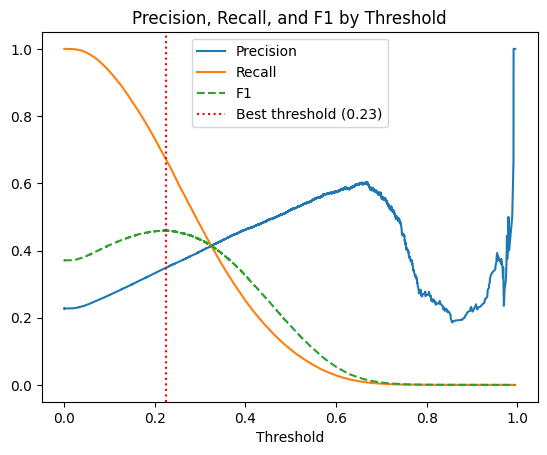

Best threshold (max F1): 0.2252
  Precision: 0.3493
  Recall:    0.6700
  F1:        0.4592


In [44]:
## Predicted probability that each obs in X_test will default
y_pred_proba_full = logit_full.predict_proba(X_test)[:, 1]

## Precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_full)

## Select threshold that maximizes F1 score
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

## Plot
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1", linestyle="--")
plt.axvline(best_threshold, color="red", linestyle=":", label=f"Best threshold ({best_threshold:.2f})")
plt.xlabel("Threshold")
plt.title("Precision, Recall, and F1 by Threshold")
plt.legend()
plt.show()

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"  Precision: {precision[best_idx]:.4f}")
print(f"  Recall:    {recall[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

In [45]:
## F1-optimal threshold from the full logistic model, applied to all models
threshold = best_threshold
print(f"Shared threshold: {threshold:.4f}")

## Save for use in notebook 4
import json
with open("../outputs/threshold.json", "w") as f:
    json.dump({"threshold": threshold}, f)

Shared threshold: 0.2252


### 🔷 5.2: Discriminatory Power (AUC / Gini)

In [47]:
# Helper: compute KS
def compute_ks(y_true, y_pred_proba):
    
    # Sort by predicted probability
    data = pd.DataFrame({
        "y": y_true,
        "p": y_pred_proba
    }).sort_values("p", ascending=False)
    
    # Cumulative distributions
    data["cum_bad"] = (data["y"] == 1).cumsum() / (data["y"] == 1).sum()
    data["cum_good"] = (data["y"] == 0).cumsum() / (data["y"] == 0).sum()
    
    # KS = max difference
    ks = np.max(np.abs(data["cum_bad"] - data["cum_good"]))
    
    return ks


# Store models in dict
models = {
    "Full": logit_full,
    "Intuition": logit_intuition,
    "Filter": logit_filter,
    "LASSO": logit_lasso_features,
    "Permutation": logit_perm
}

results_auc = []

for name, model in models.items():
    
    X_test_sub = X_test[model.feature_names_in_]
    y_pred_proba = model.predict_proba(X_test_sub)[:, 1]
    
    auc = roc_auc_score(y_test, y_pred_proba)
    gini = 2 * auc - 1
    ks = compute_ks(y_test, y_pred_proba)
    
    results_auc.append({
        "Model": name,
        "ROC-AUC": auc,
        "Gini": gini,
        "KS": ks
    })

df_auc = pd.DataFrame(results_auc).sort_values("ROC-AUC", ascending=False)
display(df_auc)

,Model,ROC-AUC,Gini,KS
4,Permutation,0.705634,0.411268,0.303334
3,LASSO,0.705535,0.411070,0.302866
0,Full,0.705287,0.410573,0.302543
2,Filter,0.700744,0.401487,0.295198
1,Intuition,0.699061,0.398121,0.290452


We compare model performance using **threshold-free** metrics — ROC-AUC, Gini, and KS — which measure only the model's ability to rank borrowers by default risk, regardless of where the classification cutoff is placed. These are the appropriate basis for comparing models.

- **AUC (ROC-AUC):** The probability that a randomly chosen defaulter is ranked higher than a non-defaulter. Higher is better.
- **Gini:** A rescaled version of AUC (`2 × AUC − 1`).
- **KS (Kolmogorov–Smirnov):** Maximum gap between the cumulative distributions of defaulters and non-defaulters when sorted by predicted risk.

Across all five feature selection methods, predictive performance was remarkably similar — ROC-AUC ranged narrowly from 0.699 to 0.706 — suggesting that sophisticated feature selection methods like permutation and LASSO offer minimal gains over simpler approaches in this context. That said, filter and intuition-based methods did perform noticeably worse than the top three, suggesting that while the gains from more sophisticated selection are modest, purely manual or univariate approaches leave some predictive signal on the table.

This narrow spread is a substantive finding: **feature selection method does not materially affect discriminatory power** under logistic regression. Most of the predictive signal is concentrated in a core set of variables — credit risk indicators, loan pricing, and repayment burden — and more sophisticated selection strategies yield diminishing returns. This is consistent with the linear nature of logistic regression, which cannot exploit interactions or nonlinearities beyond those manually specified.

Given these results, the choice of feature set is better guided by **interpretability and regulatory considerations** rather than predictive performance alone. The intuition-based model, which uses a small set of economically motivated variables, performs only 0.008 AUC below the best — a negligible gap in practice.

### 🔷 5.3: Calibration + Classification Metrics

In [50]:
## (a) Brier Score + Classification Metrics Table 
results_calibration = []

for name, model in models.items():
    
    X_test_sub = X_test[model.feature_names_in_]
    
    y_pred_proba = model.predict_proba(X_test_sub)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    brier = brier_score_loss(y_test, y_pred_proba)
    
    precision_val = precision_score(y_test, y_pred)
    recall_val = recall_score(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    results_calibration.append({
        "Model": name,
        "Brier Score": brier,
        "Precision": precision_val,
        "Recall": recall_val,
        "F1": f1_val,
        "Accuracy": acc
    })

df_calibration = pd.DataFrame(results_calibration).sort_values("Brier Score")
display(df_calibration)

,Model,Brier Score,Precision,Recall,F1,Accuracy
4,Permutation,0.159639,0.350052,0.668632,0.459526,0.642240
3,LASSO,0.159671,0.350271,0.666442,0.459196,0.642937
0,Full,0.159686,0.349313,0.670029,0.459218,0.641046
1,Intuition,0.160993,0.341784,0.669473,0.452536,0.631553
2,Filter,0.163013,0.383005,0.503576,0.435092,0.702558


We evaluate model performance using the Brier score and classification metrics at a shared threshold derived from the full model's F1-optimal operating point (threshold = 0.225).

- **Brier Score:** Measures how close predicted probabilities are to actual outcomes (lower is better). Threshold-free.
- **Precision / Recall / F1 / Accuracy:** Classification metrics at the shared threshold.

#### Brier Score
Brier scores are very similar across all models, ranging narrowly from 0.159 to 0.163, indicating that probability calibration is comparable across feature selection methods — all models are similarly well-calibrated in terms of how confidently and accurately they assign default probabilities. The filter-based method has the slightly worst Brier score, consistent with its weaker overall performance

#### Precision and Recall
The precision-recall tradeoff reveals an interesting divergence. Permutation, LASSO, and full feature models all prioritize recall — catching around 67% of actual defaulters at the cost of low precision around 0.35, meaning roughly two-thirds of predicted defaults are false alarms. Filter-based selection behaves strikingly differently — precision improves to 0.38 but recall drops sharply to 0.50, missing significantly more actual defaulters in exchange for fewer false positives. In a credit risk context where missing an actual defaulter is typically more costly than a false rejection, the high-recall models are generally preferable — though the right tradeoff ultimately depends on the specific business objective and the relative costs of each type of error.

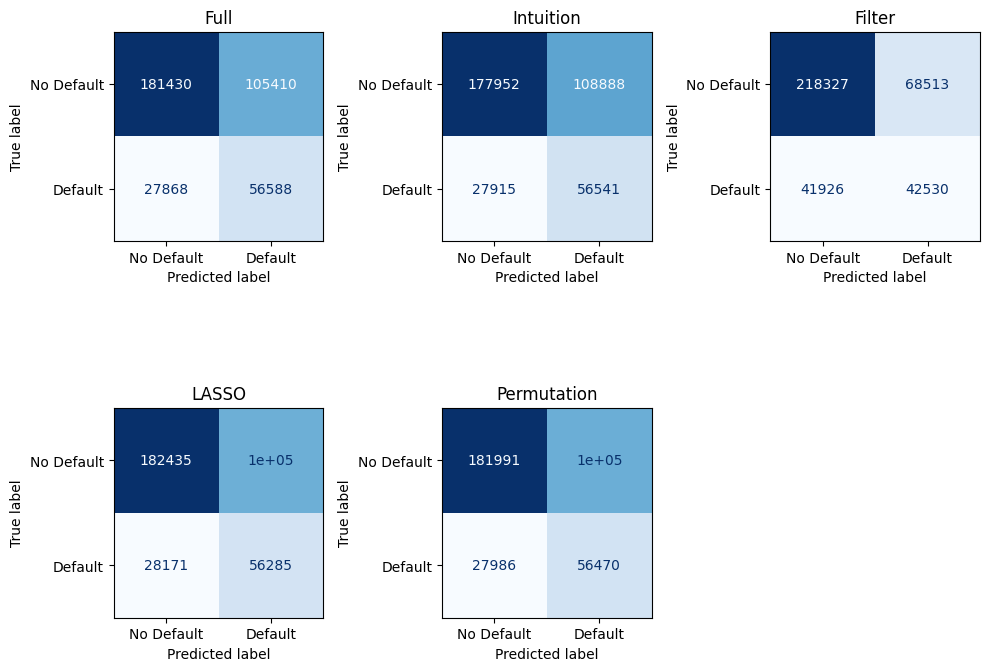

In [52]:
## (b) Confusion Matrix — 3x2 Plot
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

labels = ["No Default", "Default"]

for i, (name, model) in enumerate(models.items()):
    
    X_test_sub = X_test[model.feature_names_in_]
    y_pred_proba = model.predict_proba(X_test_sub)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name)

# Hide last subplot instead of deleting
axes[-1].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

The confusion matrices confirm the patterns discussed above. Compared to the previous run (train-only models), the matrices are notably more similar across specifications — the refit on train+val improved calibration and reduced the gap between model groups.

A mild grouping still remains:
- **Full, LASSO-features, and Intuition (C=10 or C=0.1)** identify more true defaults but also flag more non-defaulters incorrectly, reflecting higher recall at this threshold.
- **Permutation and Filter (C=0.01)** are more conservative, flagging fewer non-defaulters but also missing more actual defaults.

The differences are substantially smaller than before, and the similar Brier scores confirm this is driven by probability scale rather than genuine differences in model quality.

### 🔷 5.4: Interpretation

#### Which Model Is Best?

**AUC/Gini Comparison**

| Model | AUC | F1 | Notes |
|---|---|---|---|
| Permutation | 0.706 | 0.460 | Best AUC, data-driven selection |
| LASSO | 0.706 | 0.459 | Near-identical AUC, best F1 |
| Full | 0.705 | 0.459 | Benchmark |
| Filter | 0.701 | 0.435 | Lower recall, misses interaction features |
| Intuition | 0.699 | 0.453 | Interpretable, economically grounded |

AUC differences are negligible (< 0.007), suggesting feature selection method has minimal impact on overall discriminative performance.

**Practical Guidance**

- **Best predictive performance:** Permutation or LASSO — marginally highest AUC with a more targeted feature set
- **Interpretability / regulatory use:** Intuition — small, defensible feature set with clear economic rationale, closely matching industry standard for credit scoring models
- **Research benchmark:** Full model as baseline, Permutation as best data-driven specification

#### Why Feature Selection Method Barely Matters

The intuition-based model already captures the main drivers of default risk — credit quality (`fico_range_low`, `sub_grade`), repayment burden (`dti`, `payment_to_income`), and utilization (`revol_util`, `fico_util_interaction`). These variables carry most of the predictive signal. Additional features selected by data-driven methods are correlated with this core set and contribute only marginally.

This is a well-known property of logistic regression: being a linear model, it cannot exploit nonlinear relationships or interactions beyond what is manually specified. This caps the gains from adding more features. Tree-based models (Notebook 4) can automatically discover such patterns and may achieve meaningfully higher performance.

#### A Note on Filter-Based Selection and `fico_util_interaction`

The filter method did not select `fico_util_interaction` despite it being the 2nd most important feature by permutation importance. This illustrates a key limitation of filter methods: the univariate F-test evaluates each feature independently against the target, and cannot detect interaction terms whose value arises from the **joint** relationship between `fico_range_low` and `revol_util`. Permutation importance, which evaluates features within a fitted model, correctly identifies this interaction as highly informative.

---
## Section 6: Feature Importance

We examine which features drive model predictions using two complementary approaches: **model coefficients** and **permutation importance**.

**(1) Coefficient-Based Importance (Full vs. Permutation Models)**
* We compare the magnitude of logistic regression coefficients across the full-feature model and the permutation-selected model.
* Coefficients reflect how strongly each feature affects predicted default risk (in log-odds terms).
* <span style="color:blue">→ how the model internally weights features</span> 

**(2) Permutation Importance**
* We measure feature importance by evaluating how much model performance decreases when each feature is randomly shuffled.
* If shuffling a feature significantly reduces performance, it is important for prediction.  
* This method captures the **actual contribution to predictive accuracy**, including interactions and nonlinear effects.
* <span style="color:blue">→ how much features actually matter for prediction</span>  

Together, these provide a more complete understanding of feature importance.

### 🔷 6.1: Coefficient-based feature importance (Full vs Permutation models)

In [57]:
## Helper: plot feature importance

def plot_feature_importance(importance_df, title, top_n=20):
    plot_df = importance_df.head(top_n).sort_values("importance")
    
    plt.figure(figsize=(8, 6))
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [58]:
# --- Full model ---
feature_names_full = logit_full.named_steps["preprocess"].get_feature_names_out()
coef_full = logit_full.named_steps["model"].coef_[0]

coef_importance_full = pd.DataFrame({
    "feature": feature_names_full,
    "coef_full": coef_full,
    "abs_full": abs(coef_full)
})


# --- Permutation-based model ---
feature_names_perm = logit_perm.named_steps["preprocess"].get_feature_names_out()
coef_perm = logit_perm.named_steps["model"].coef_[0]

coef_importance_perm = pd.DataFrame({
    "feature": feature_names_perm,
    "coef_perm": coef_perm,
    "abs_perm": abs(coef_perm)
})

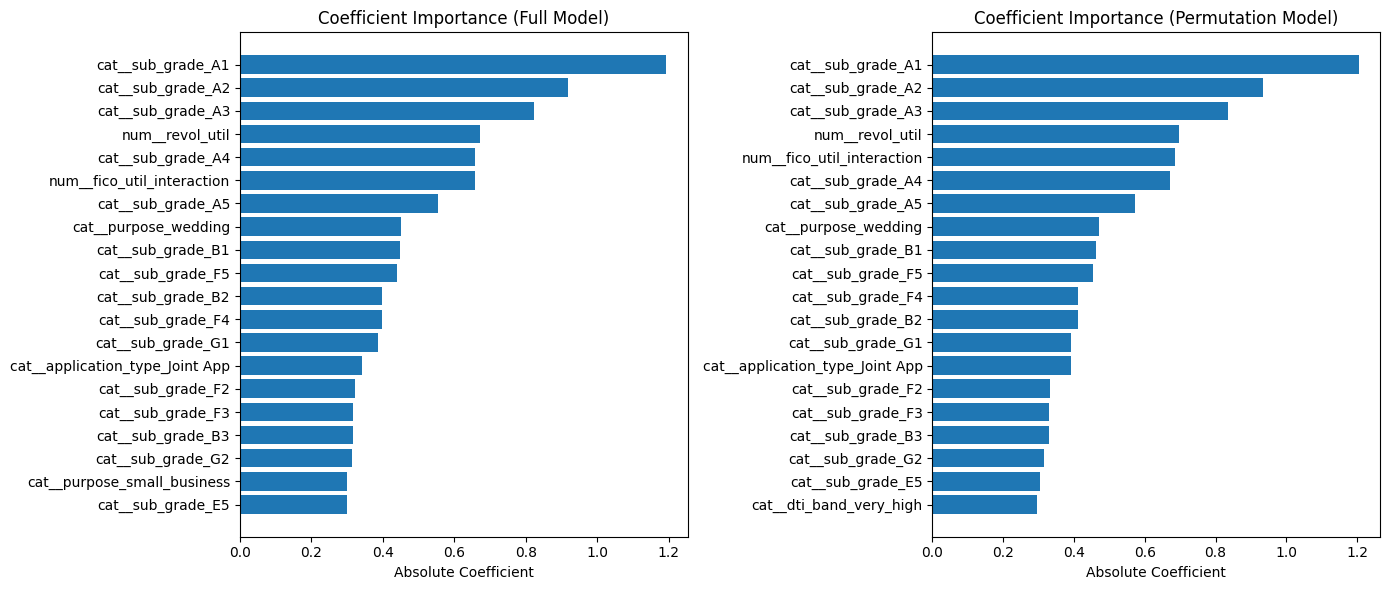

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Full model: own ranking ---
top_full = coef_importance_full.sort_values("abs_full", ascending=False).head(20).sort_values("abs_full")

axes[0].barh(top_full["feature"], top_full["abs_full"])
axes[0].set_title("Coefficient Importance (Full Model)")
axes[0].set_xlabel("Absolute Coefficient")


# --- Permutation model: own ranking ---
top_perm = coef_importance_perm.sort_values("abs_perm", ascending=False).head(20).sort_values("abs_perm")

axes[1].barh(top_perm["feature"], top_perm["abs_perm"])
axes[1].set_title("Coefficient Importance (Permutation Model)")
axes[1].set_xlabel("Absolute Coefficient")


plt.tight_layout()
plt.show()

The top features are largely consistent across both models, with **credit risk indicators (especially sub-grade categories) clearly dominating**. This reinforces that creditworthiness measures are the primary drivers of default prediction.

Differences emerge mainly among lower-ranked features. The permutation-based model places relatively more emphasis on variables such as **application type and home ownership**, reflecting the removal of redundant features and a shift toward variables that remain informative after accounting for multicollinearity.

Overall, while the core drivers of default risk are stable, feature selection mainly affects secondary predictors by reducing redundancy and slightly adjusting their relative importance.

### 🔷 6.2: Permutation importance on test set

In [62]:
perm_full_result = permutation_importance(
    logit_full,
    X_test[features_full],
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_importance_full = pd.DataFrame({
    "feature": features_full,
    "importance": perm_full_result.importances_mean,
    "importance_std": perm_full_result.importances_std
}).sort_values("importance", ascending=False)

display(perm_importance_full.head(20))

,feature,importance,importance_std
17,revol_util,0.089569,0.000723
61,fico_util_interaction,0.052982,0.000587
4,sub_grade,0.044534,0.000454
1,term,0.019765,0.000504
3,installment,0.012357,0.000178
57,total_il_high_credit_limit,0.008577,0.000155
14,open_acc,0.007330,0.000097
56,total_bc_limit,0.006844,0.000113
59,income_to_loan_ratio,0.006707,0.000288
58,credit_age,0.005461,0.000119


Permutation importance highlights the features that contribute most to predictive performance. The top drivers include **loan characteristics (term, installment, interest rate)** and **credit risk indicators (sub-grade, total credit limits, total accounts)**, confirming that both pricing and overall credit capacity are central to default prediction.

Borrower financial condition variables such as **DTI, home ownership, and balance-related measures (e.g., total balances, average balances)** also play an important role, though to a lesser extent. In addition, **credit history and account activity variables** (e.g., FICO score, recent account openings, utilization measures) contribute modestly to performance.

Overall, importance values are relatively small and decline gradually, indicating that predictive power is **spread across many features rather than driven by a few dominant variables**, which is consistent with the model’s moderate performance.

---
## Section 7: Discussions

#### How to Improve Prediction Performance

The current results (e.g., confusion matrices and recall) suggest that the model still misses a meaningful number of default cases. Below are several directions to improve predictive performance:

- **Tune the decision threshold**  
  Select a threshold based on the relative cost of false negatives (missing defaults) and false positives, rather than using a fixed value.

- **Address class imbalance**  
  Use class weights or resampling techniques to better capture the minority class (defaults).

- **Improve feature engineering**  
  Construct additional features such as ratios, interactions (e.g., `dti × int_rate`), or binned variables to better capture nonlinear relationships.

- **Incorporate macroeconomic or local features**  
  Add external variables such as local unemployment rates or state-level economic indicators. These can capture broader economic conditions that affect repayment ability. It is important to align these variables with the loan origination date to avoid using future information.

- **Try more flexible models**  
  Tree-based methods (e.g., Random Forest, XGBoost, LightGBM) can automatically capture nonlinearities and interactions and may improve performance.

Overall, improving performance will likely require a combination of better features, appropriate threshold selection, and more flexible modeling approaches.